<a href="https://colab.research.google.com/github/Catherine-23-Codes/CART_SC3_PS3/blob/main/Taco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.listdir("/kaggle/input")

[]

In [2]:
import json

with open("annotations (1).json") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['info', 'images', 'annotations', 'scene_annotations', 'licenses', 'categories', 'scene_categories'])


In [3]:
for c in data["categories"]:
    print(c["name"])

Aluminium foil
Battery
Aluminium blister pack
Carded blister pack
Other plastic bottle
Clear plastic bottle
Glass bottle
Plastic bottle cap
Metal bottle cap
Broken glass
Food Can
Aerosol
Drink can
Toilet tube
Other carton
Egg carton
Drink carton
Corrugated carton
Meal carton
Pizza box
Paper cup
Disposable plastic cup
Foam cup
Glass cup
Other plastic cup
Food waste
Glass jar
Plastic lid
Metal lid
Other plastic
Magazine paper
Tissues
Wrapping paper
Normal paper
Paper bag
Plastified paper bag
Plastic film
Six pack rings
Garbage bag
Other plastic wrapper
Single-use carrier bag
Polypropylene bag
Crisp packet
Spread tub
Tupperware
Disposable food container
Foam food container
Other plastic container
Plastic glooves
Plastic utensils
Pop tab
Rope & strings
Scrap metal
Shoe
Squeezable tube
Plastic straw
Paper straw
Styrofoam piece
Unlabeled litter
Cigarette


In [4]:
class_map = {
    "Aluminium foil": "metal",
    "Drink can": "metal",
    "Food Can": "metal",

    "Glass bottle": "glass",
    "Glass jar": "glass",
    "Broken glass": "glass",

    "Paper cup": "paper",
    "Normal paper": "paper",
    "Paper bag": "paper",
    "Pizza box": "paper",

    "Food waste": "organic",

    "Clear plastic bottle": "plastic",
    "Other plastic bottle": "plastic",
    "Plastic straw": "plastic",
    "Plastic lid": "plastic",
    "Plastic film": "plastic",
}

In [5]:
print("Images:", len(data["images"]))
print("Annotations:", len(data["annotations"]))
print("Categories:", len(data["categories"]))

Images: 1500
Annotations: 4784
Categories: 60


In [6]:
from collections import Counter

labels = [ann["category_id"] for ann in data["annotations"]]
print(Counter(labels))

Counter({59: 667, 58: 517, 36: 451, 5: 285, 29: 273, 39: 260, 12: 229, 7: 209, 55: 157, 9: 138, 57: 112, 6: 104, 21: 104, 50: 99, 14: 93, 33: 82, 8: 80, 27: 77, 20: 67, 17: 64, 0: 62, 40: 61, 4: 50, 16: 45, 31: 42, 42: 39, 45: 38, 49: 37, 10: 34, 38: 31, 18: 30, 51: 29, 34: 27, 52: 20, 46: 15, 22: 13, 30: 12, 32: 12, 15: 11, 11: 10, 28: 10, 43: 9, 25: 8, 54: 7, 53: 7, 23: 6, 26: 6, 2: 6, 47: 6, 13: 5, 37: 5, 56: 4, 48: 4, 44: 4, 41: 3, 19: 3, 1: 2, 24: 2, 3: 1})


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import random

In [9]:
with open("annotations.json") as f:
    data = json.load(f)

In [10]:
categories = {cat["id"]: cat["name"] for cat in data["categories"]}

In [11]:
ann = random.choice(data["annotations"])
cat_name = categories[ann["category_id"]]
bbox = ann["bbox"]

print("Detected waste:", cat_name)
print("Bounding box:", bbox)

Detected waste: Cigarette
Bounding box: [280.0, 944.0, 40.0, 16.0]


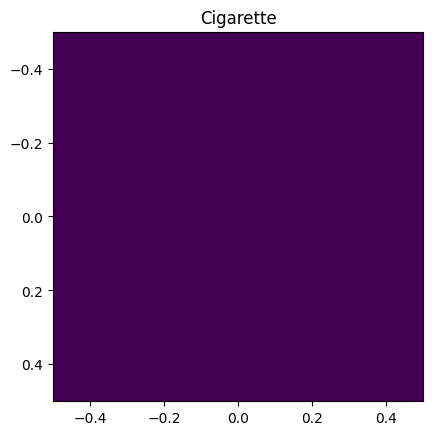

In [12]:
fig, ax = plt.subplots()

# create blank image
ax.imshow([[0]])

# bounding box
x, y, w, h = bbox
rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')

ax.add_patch(rect)
plt.title(cat_name)

plt.show()

In [13]:
def waste_type(name):
    if "plastic" in name.lower():
        return "Plastic Bin"
    elif "glass" in name.lower():
        return "Glass Bin"
    elif "paper" in name.lower():
        return "Paper Bin"
    elif "metal" in name.lower() or "can" in name.lower():
        return "Metal Bin"
    elif "food" in name.lower():
        return "Organic Bin"
    else:
        return "General Waste"

print("Send to:", waste_type(cat_name))

Send to: General Waste


In [14]:
def waste_type(name):
    name = name.lower()

    if "plastic" in name or "wrapper" in name or "bag" in name or "straw" in name:
        return "Plastic Bin"

    elif "glass" in name:
        return "Glass Bin"

    elif "paper" in name or "carton" in name or "box" in name:
        return "Paper Bin"

    elif "metal" in name or "can" in name or "foil" in name:
        return "Metal Bin"

    elif "food" in name:
        return "Organic Bin"

    elif "cigarette" in name or "shoe" in name:
        return "General Waste"

    else:
        return "General Waste"

In [15]:
print("Detected waste:", cat_name)
print("Send to:", waste_type(cat_name))

Detected waste: Cigarette
Send to: General Waste


In [16]:
print("Number of images:", len(data["images"]))
print("Number of annotations:", len(data["annotations"]))
print("Number of categories:", len(data["categories"]))

Number of images: 1500
Number of annotations: 4784
Number of categories: 60


In [17]:
category_names = {c["id"]: c["name"] for c in data["categories"]}

waste_counts = {}

for ann in data["annotations"]:
    name = category_names[ann["category_id"]]
    waste_counts[name] = waste_counts.get(name, 0) + 1

print(waste_counts)

{'Glass bottle': 104, 'Meal carton': 30, 'Other carton': 93, 'Clear plastic bottle': 285, 'Plastic bottle cap': 209, 'Drink can': 229, 'Food Can': 34, 'Other plastic bottle': 50, 'Pop tab': 99, 'Aerosol': 10, 'Glass cup': 6, 'Other plastic wrapper': 260, 'Styrofoam piece': 112, 'Plastic film': 451, 'Other plastic': 273, 'Drink carton': 45, 'Metal bottle cap': 80, 'Disposable food container': 38, 'Normal paper': 82, 'Paper cup': 67, 'Single-use carrier bag': 61, 'Tissues': 42, 'Toilet tube': 5, 'Crisp packet': 39, 'Plastic lid': 77, 'Metal lid': 10, 'Egg carton': 11, 'Plastic straw': 157, 'Paper bag': 27, 'Disposable plastic cup': 104, 'Broken glass': 138, 'Plastic utensils': 37, 'Glass jar': 6, 'Food waste': 8, 'Squeezable tube': 7, 'Spread tub': 9, 'Shoe': 7, 'Garbage bag': 31, 'Aluminium foil': 62, 'Six pack rings': 5, 'Foam cup': 13, 'Paper straw': 4, 'Corrugated carton': 64, 'Unlabeled litter': 517, 'Aluminium blister pack': 6, 'Battery': 2, 'Rope & strings': 29, 'Cigarette': 667, 

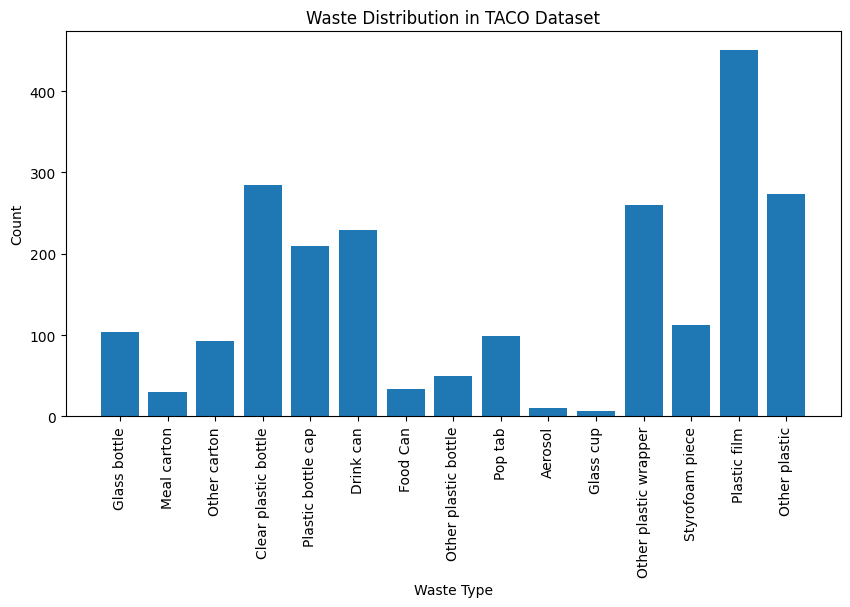

In [18]:
import matplotlib.pyplot as plt

names = list(waste_counts.keys())[:15]
values = list(waste_counts.values())[:15]

plt.figure(figsize=(10,5))
plt.bar(names, values)

plt.xticks(rotation=90)
plt.title("Waste Distribution in TACO Dataset")
plt.xlabel("Waste Type")
plt.ylabel("Count")

plt.show()

In [19]:
import random

ann = random.choice(data["annotations"])

print("Category ID:", ann["category_id"])
print("Bounding box:", ann["bbox"])

Category ID: 7
Bounding box: [3577.0, 1127.0, 57.0, 46.0]


In [20]:
cat_id = ann["category_id"]

print("Detected waste:", category_names[cat_id])

Detected waste: Plastic bottle cap


In [21]:
from collections import Counter

top10 = Counter(waste_counts).most_common(10)

for name, count in top10:
    print(name, count)

Cigarette 667
Unlabeled litter 517
Plastic film 451
Clear plastic bottle 285
Other plastic 273
Other plastic wrapper 260
Drink can 229
Plastic bottle cap 209
Plastic straw 157
Broken glass 138


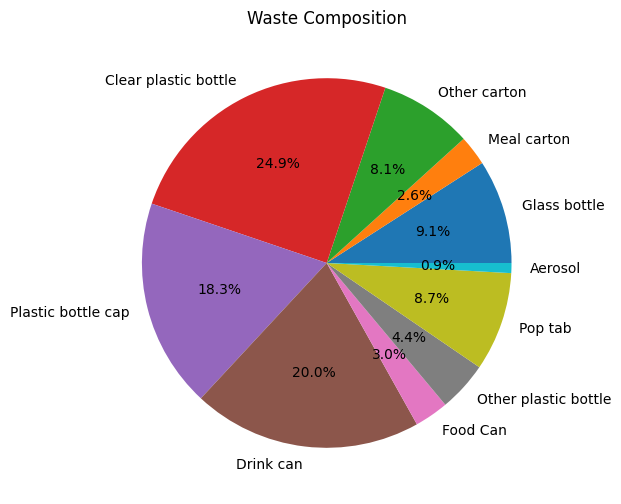

In [22]:
import matplotlib.pyplot as plt

labels = list(waste_counts.keys())[:10]
sizes = list(waste_counts.values())[:10]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Waste Composition")
plt.show()

In [23]:
sample_items = ["Plastic straw", "Glass bottle", "Pizza box", "Food waste"]

for item in sample_items:
    print(item, "→", waste_type(item))

Plastic straw → Plastic Bin
Glass bottle → Glass Bin
Pizza box → Paper Bin
Food waste → Organic Bin
